# Análisis de los datos

1. [Análisis univariante](#Análisis-univariante)  
    - [Planetas](#Planetas)
    - [Estrellas](#Estrellas)
    - [Sistemas](#Sistemas)
2. [Análisis bivariante](#Análisis-bivariante)  
    - [Radio vs Masa del Planeta](#Radio-vs-Masa-del-Planeta)
    - [Metalicidad vs Masa del planeta](#Metalicidad-de-la-Estrella-vs-Masa-del-Planeta)
    - [Edad de la Estrella vs Núm. Planetas](#Edad-de-la-Estrella-vs-Número-de-Planetas)
3. [Análisis por hipótesis](#Análisis-por-hipótesis)  
    - [Hipótesis 1](#Hipótesis-1)
    - [Hipótesis 2](#Hipótesis-2)
    - [Hipótesis 3](#Hipótesis-3)
    - [Hipótesis 4](#Hipótesis-4)
    - [Hipótesis 5](#Hipótesis-5)
    - [Hipótesis 6](#Hipótesis-6)

Cargamos ficheros

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import math

In [2]:
planets = pd.read_csv('../data/dataclean_pl.csv') # Ruta lógica desde donde se encuentra el dataset
stars = pd.read_csv('../data/dataclean_st.csv')
systems = pd.read_csv('../data/dataclean_sy.csv')

In [3]:
# Configuraciones de estilo de gráficos
sns.set_theme(color_codes=True)
plt.style.use('petroff10')

## Análisis univariante

### Planetas

In [4]:
planets.head()

,rowid,pl_name,pl_rade,pl_bmasse,pl_eqt,pl_orbper,pl_orbsmax,pl_insol
0,1,11 Com b,12.2,4914.898486,NaN,323.21000,1.178,NaN
1,2,11 UMi b,12.3,4684.814200,NaN,516.21997,1.530,NaN
2,3,14 And b,13.1,1131.151301,NaN,186.76000,0.775,NaN
3,4,14 Her b,12.5,2828.672822,NaN,1766.41000,2.839,NaN
4,5,16 Cyg B b,13.5,565.737400,NaN,798.50000,1.660,NaN


In [5]:
planets.info()

<class 'pandas.DataFrame'>
RangeIndex: 6053 entries, 0 to 6052
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rowid       6053 non-null   int64  
 1   pl_name     6053 non-null   str    
 2   pl_rade     6053 non-null   float64
 3   pl_bmasse   6053 non-null   float64
 4   pl_eqt      4534 non-null   float64
 5   pl_orbper   5728 non-null   float64
 6   pl_orbsmax  6046 non-null   float64
 7   pl_insol    4267 non-null   float64
dtypes: float64(6), int64(1), str(1)
memory usage: 378.4 KB


In [6]:
planets.describe().T

,count,mean,std,min,25%,50%,75%,max
rowid,6053.0,3079.737816,1.773408e+03,1.000000,1551.000000,3073.000000,4616.000000,6.153000e+03
pl_rade,6053.0,5.788233,5.299032e+00,0.309800,1.820000,2.830000,11.900000,7.734210e+01
pl_bmasse,6053.0,390.244194,1.114627e+03,0.020000,4.180000,9.110000,181.162192,9.534852e+03
pl_eqt,4534.0,911.914742,4.636641e+02,34.000000,566.000000,817.000000,1163.000000,4.050000e+03
pl_orbper,5728.0,73312.084606,5.313031e+06,0.112007,4.362964,11.134532,39.651990,4.020000e+08
pl_orbsmax,6046.0,15.015260,3.428428e+02,0.003857,0.052000,0.100860,0.286765,1.900000e+04
pl_insol,4267.0,418.428751,1.301359e+03,0.000300,23.484700,97.846000,373.549000,4.490000e+04


RADIOS DE LOS PLANETAS

Vemos que la mayoría de los planetas tienen un tamaño cercano al de la Tierra. Sin embargo, encontramos que hay otra tendencia (mucho menor) de tamaños alrededor de 15 veces el de la Tierra.
En el boxplot observamos que hay muy poquitos outliers, casi todos los datos se concentran dentro de los whiskers.

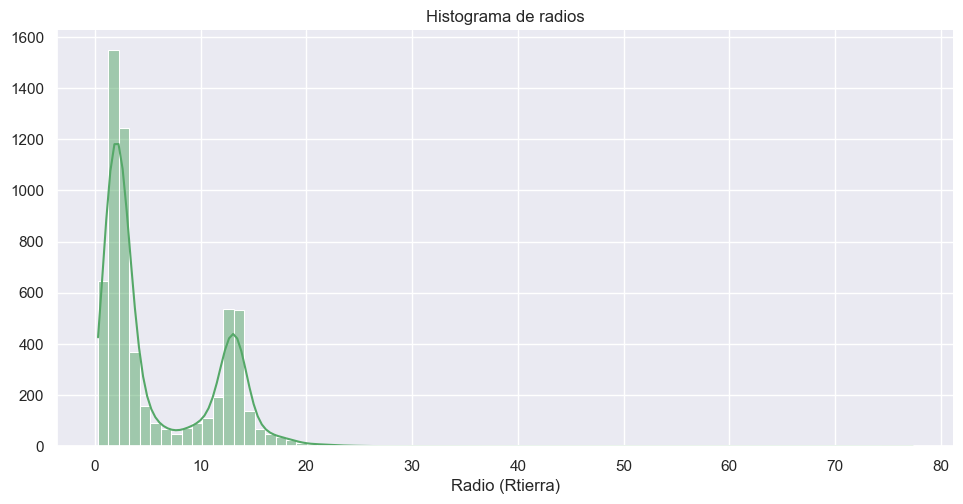

In [7]:
ax = sns.displot(planets['pl_rade'],
            kind='hist',
            kde=True,
            color='g',
            bins=78,
            height=5,
            aspect =2)
plt.title('Histograma de radios')
plt.xlabel('Radio (Rtierra)')
plt.ylabel('');

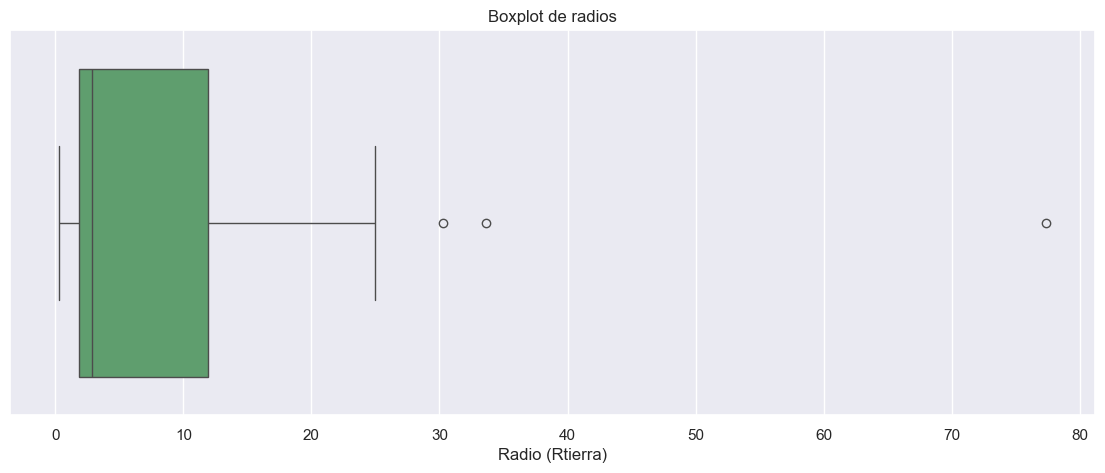

In [8]:
plt.figure(figsize=(14,5))
sns.boxplot(x=planets['pl_rade'],color='g')
plt.title('Boxplot de radios')
plt.xlabel('Radio (Rtierra)');

MASAS DE LOS PLANETAS

In [9]:
planets['pl_bmasse'].describe()


count    6053.000000
mean      390.244194
std      1114.626983
min         0.020000
25%         4.180000
50%         9.110000
75%       181.162192
max      9534.852210
Name: pl_bmasse, dtype: float64

La distribución de masas es mucho más significativa que la de los tamaños. La mayoría de los planetas tienen masas similares al de la Tierra, ya que el cuartil Q1 y la mediana se encuentran en 4.18 M<sub>Tierra</sub> y 9.11 M<sub>Tierra</sub>, respectivamente. Y es que, si hacemos zoom, vemos que más de la mitad de los planetas del catálogo no superan las 10 M<sub>Tierra</sub>.  
Hay muchos outliers en el boxplot, no obstante, no es muy influyente ya que la mayoría de los planetas no tienen una gran masa.

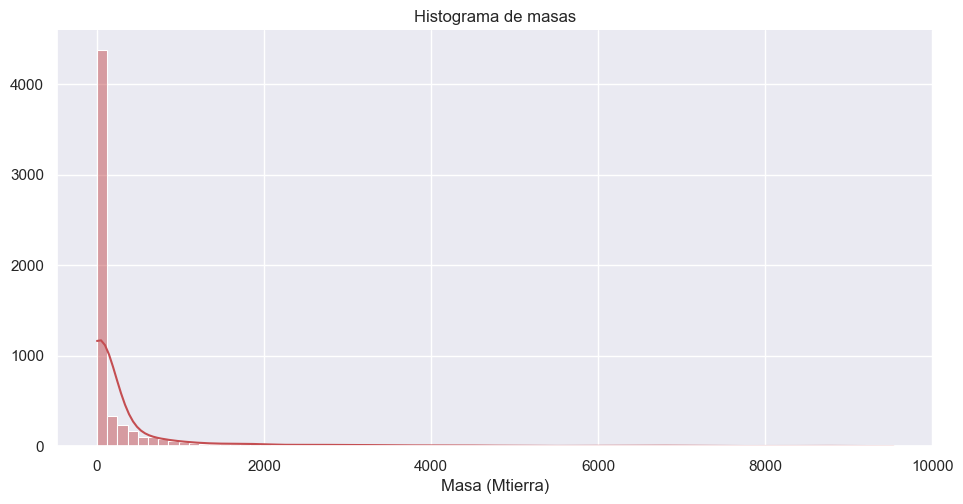

In [10]:
sns.displot(planets['pl_bmasse'],
            kind='hist',
            kde=True,
            color='r',
            bins=78,
            height=5,
            aspect =2)
plt.title('Histograma de masas')
plt.xlabel('Masa (Mtierra)')
plt.ylabel('');

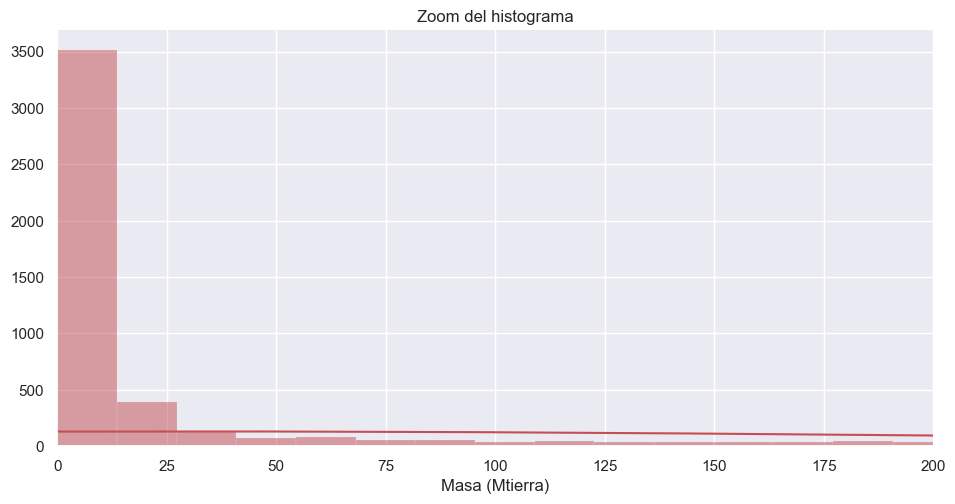

In [11]:
sns.displot(planets['pl_bmasse'],
            kind='hist',
            kde=True,
            color='r',
            bins=700,
            height=5,
            aspect =2)
plt.title('Zoom del histograma')
plt.xlabel('Masa (Mtierra)')
plt.ylabel('')
plt.xlim(0,200);

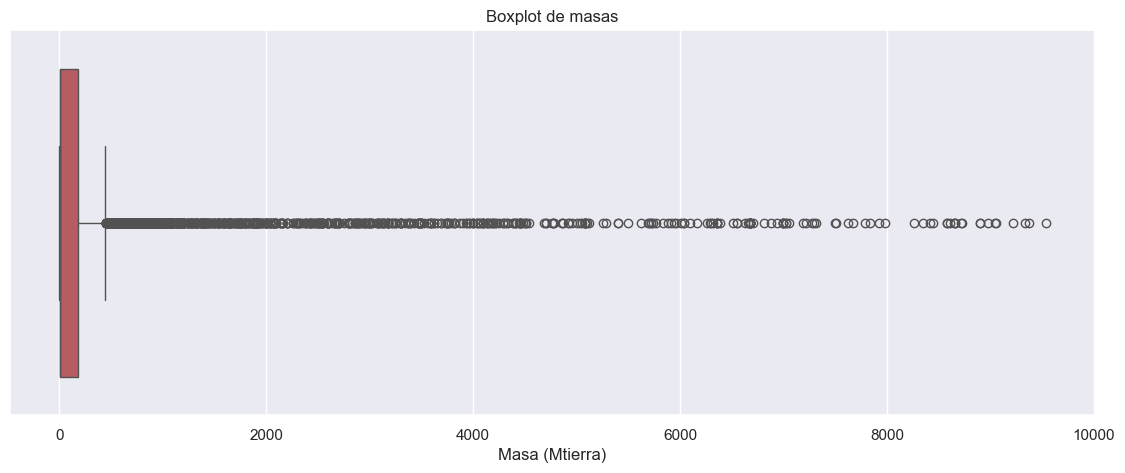

In [12]:
plt.figure(figsize=(14,5))
sns.boxplot(x=planets['pl_bmasse'],color='r')
plt.title('Boxplot de masas')
plt.xlabel('Masa (Mtierra)');

TEMPERATURAS DE EQUILIBRIO

En lo referente a las temperaturas, observamos una mayor dispersión.

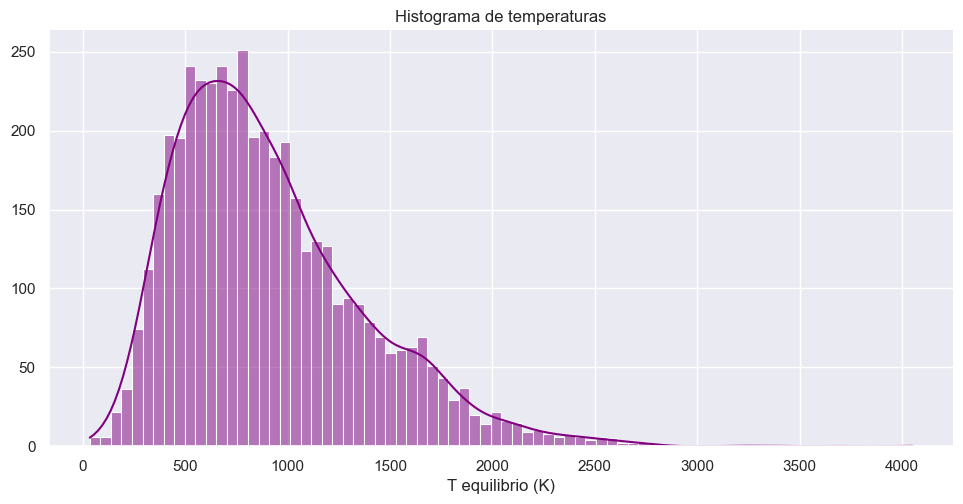

In [13]:
sns.displot(planets['pl_eqt'],
            kind='hist',
            kde=True,
            color='purple',
            bins=78,
            height=5,
            aspect =2)
plt.title('Histograma de temperaturas')
plt.xlabel('T equilibrio (K)')
plt.ylabel('');

### Estrellas

In [14]:
stars.head()

,rowid,hostname,st_teff,st_rad,st_mass,st_met,st_spectype,st_age,st_rotp
0,1,11 Com,4874.0,13.76,2.09,-0.26,G8 III,NaN,NaN
1,2,11 UMi,4213.0,29.79,2.78,-0.02,K4 III,1.56,NaN
2,3,14 And,4888.0,11.55,1.78,-0.21,K0 III,4.50,NaN
3,4,14 Her,5338.0,0.93,0.97,0.43,K0,4.60,NaN
4,5,16 Cyg B,5750.0,1.13,1.08,0.06,G3 V,7.40,NaN


In [15]:
stars.info()

<class 'pandas.DataFrame'>
RangeIndex: 6053 entries, 0 to 6052
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rowid        6053 non-null   int64  
 1   hostname     6053 non-null   str    
 2   st_teff      5772 non-null   float64
 3   st_rad       5751 non-null   float64
 4   st_mass      6048 non-null   float64
 5   st_met       5519 non-null   float64
 6   st_spectype  2265 non-null   str    
 7   st_age       4770 non-null   float64
 8   st_rotp      877 non-null    float64
dtypes: float64(6), int64(1), str(2)
memory usage: 425.7 KB


In [16]:
stars.describe().T

,count,mean,std,min,25%,50%,75%,max
rowid,6053.0,3079.737816,1773.408458,1.0000,1551.000,3073.00000,4616.00,6153.000
st_teff,5772.0,5386.459238,1669.145183,575.0000,4900.750,5550.00000,5900.00,57000.000
st_rad,5751.0,1.509244,3.977023,0.0115,0.770,0.95271,1.25,88.475
st_mass,6048.0,0.936324,0.396252,0.0094,0.771,0.94000,1.09,10.940
st_met,5519.0,0.015632,0.189033,-1.0000,-0.080,0.02000,0.13,0.790
st_age,4770.0,4.375728,2.988726,0.0000,2.340,3.98000,5.62,16.100
st_rotp,877.0,52.837950,312.556874,-35.7320,12.454,23.07000,40.00,7900.000


TEMPERATURA EFECTIVA

La temperatura de nuestro Sol es de unos 5 772 K. La mayoría de las estrellas se encuentran en torno a ese valor. El cuartil Q3 y la mediana son 5550 K y 5900 K, respectivamente. Es decir, que un cuarto de las estrellas se encuentran entre esos dos valores.

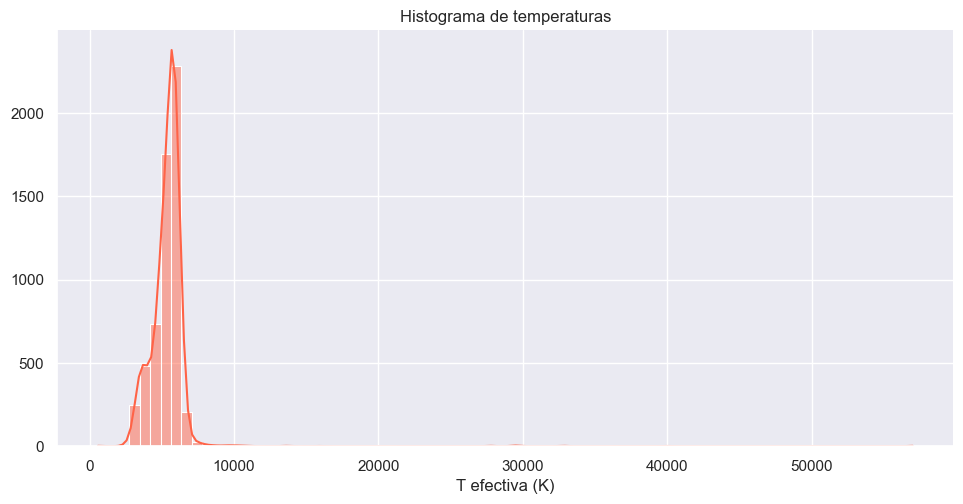

In [17]:
sns.displot(stars['st_teff'],
            kind='hist',
            kde=True,
            bins=78,
            color='tomato',
            height=5,
            aspect =2)
plt.title('Histograma de temperaturas')
plt.xlabel('T efectiva (K)')
plt.ylabel('');

RADIOS DE LAS ESTRELLAS

En caso de los radios también son muy similares, la mediana se encuentra en 0.95271 radios terrestres.

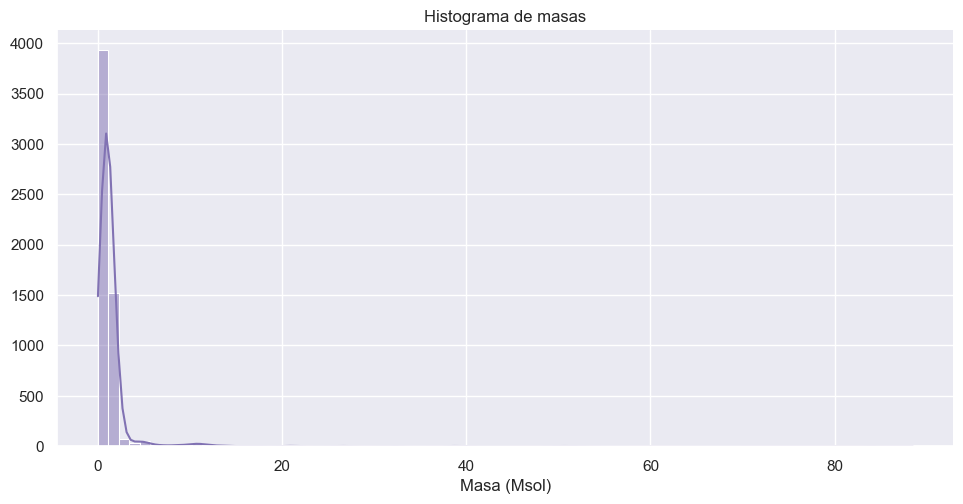

In [18]:
sns.displot(stars['st_rad'],
            kind='hist',
            kde=True,
            bins=78,
            color='m',
            height=5,
            aspect =2)
plt.title('Histograma de masas')
plt.xlabel('Masa (Msol)')
plt.ylabel('');

MASA

Aunque hay una mayor dispersión, podemos percibir que estrellas como nuestro Sol son las más comunes para sistemas planetarios.

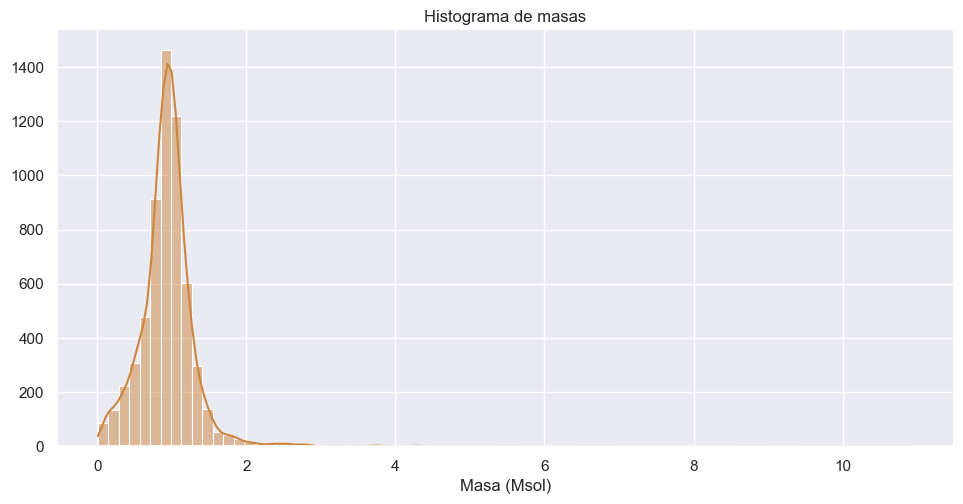

In [19]:
sns.displot(stars['st_mass'],
            kind='hist',
            kde=True,
            bins=78,
            color='peru',
            height=5,
            aspect =2)
plt.title('Histograma de masas')
plt.xlabel('Masa (Msol)')
plt.ylabel('');

### Sistemas

In [20]:
systems.head()

,rowid,sy_dist,sy_pnum,discoverymethod,disc_year
0,1,93.1846,1,Radial Velocity,2007
1,2,125.3210,1,Radial Velocity,2009
2,3,75.4392,1,Radial Velocity,2008
3,4,17.9323,2,Radial Velocity,2002
4,5,21.1397,1,Radial Velocity,1996


DISTANCIAS DE LOS SISTEMAS

In [21]:
systems['sy_dist'].describe()

count    6053.000000
mean      713.948388
std      1217.183536
min         1.301190
25%       102.275000
50%       377.483000
75%       833.165000
max      8500.000000
Name: sy_dist, dtype: float64

Vemos que la mayor parte de los sistemas planetarios se encuentran más cerca. Tiene cierto sentido que encontremos más fácilmente los sistemas que estén cerca.

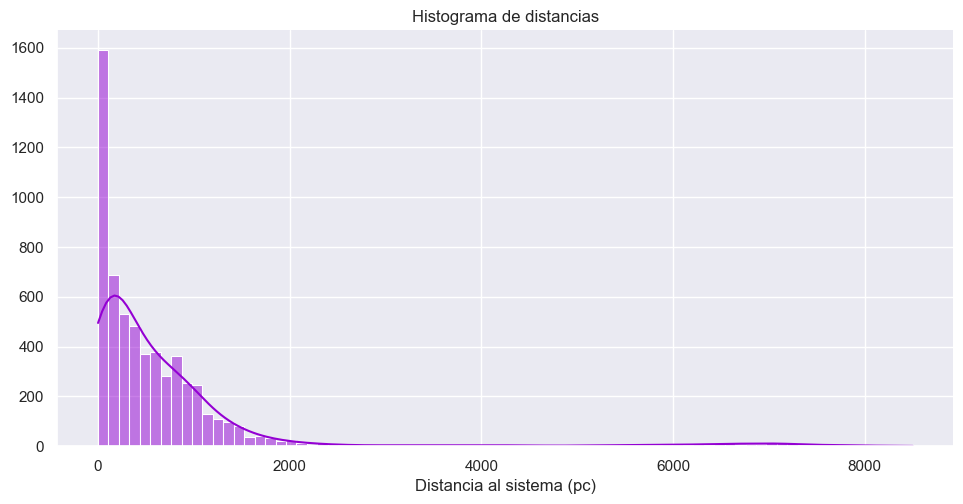

In [22]:
sns.displot(systems['sy_dist'],
            kind='hist',
            kde=True,
            bins=78,
            color='darkviolet',
            height=5,
            aspect =2)
plt.title('Histograma de distancias')
plt.xlabel('Distancia al sistema (pc)')
plt.ylabel('');

NÚMERO DE PLANETAS

Lo más común es encontrarnos con sistemas con un único planeta.

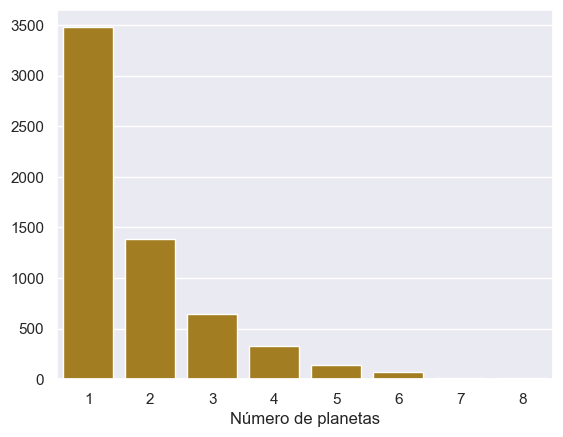

In [23]:
sns.countplot(data=systems, x='sy_pnum',color='darkgoldenrod');
plt.xlabel('Número de planetas')
plt.ylabel('');

MÉTODO Y AÑO DE DESCUBRIMIENTO

Sin duda el método por excelencia es el 

In [24]:
systems['discoverymethod'].value_counts()

discoverymethod
Transit                          4481
Radial Velocity                  1144
Microlensing                      273
Imaging                            84
Transit Timing Variations          37
Eclipse Timing Variations          14
Astrometry                          6
Orbital Brightness Modulation       6
Pulsar Timing                       5
Pulsation Timing Variations         2
Disk Kinematics                     1
Name: count, dtype: int64

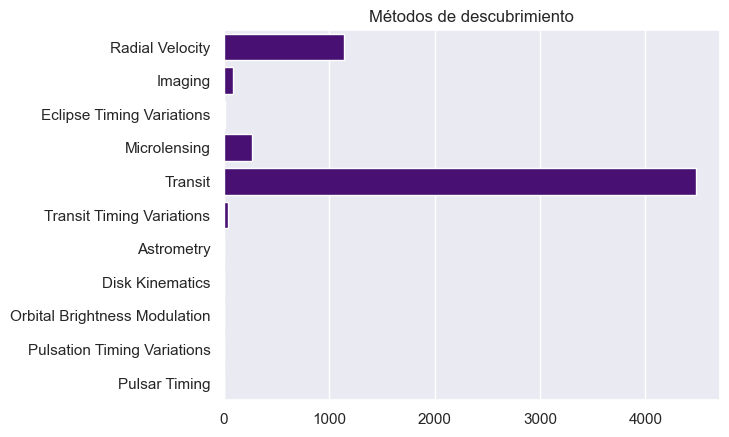

In [25]:
sns.countplot(data=systems, y='discoverymethod',color='indigo')
plt.title('Métodos de descubrimiento')
plt.xlabel('')
plt.ylabel('');

In [26]:
import plotly.graph_objs as go

# 1) Agrupar por año y contar
conteo = systems['disc_year'].value_counts().sort_index()

# 2) Crear el lineplot
fig = go.Figure(
    data=go.Scatter(x=conteo.index,
                    y=conteo.values,
                    mode='lines',
                    line=dict(width=2, color='royalblue'),
                    marker=dict(size=6)
                    )
    )

# 3) Ajustes estéticos
fig.update_layout(title='Número de descubrimientos por año',
                  xaxis_title='',
                  yaxis_title='',
                  template='plotly_white'
                  )

In [27]:
# conteo = systems['disc_year'].value_counts().sort_index()

# plt.figure(figsize=(14,5))

# conteo.plot(kind='line')

# plt.title('Número de descubrimientos por año')
# plt.xlabel('')
# plt.ylabel('');

## Análisis bivariante

In [28]:
planets.merge(stars.merge(systems)).describe().T

,count,mean,std,min,25%,50%,75%,max
rowid,6053.0,3079.737816,1.773408e+03,1.000000,1551.000000,3073.000000,4616.000000,6.153000e+03
pl_rade,6053.0,5.788233,5.299032e+00,0.309800,1.820000,2.830000,11.900000,7.734210e+01
pl_bmasse,6053.0,390.244194,1.114627e+03,0.020000,4.180000,9.110000,181.162192,9.534852e+03
pl_eqt,4534.0,911.914742,4.636641e+02,34.000000,566.000000,817.000000,1163.000000,4.050000e+03
pl_orbper,5728.0,73312.084606,5.313031e+06,0.112007,4.362964,11.134532,39.651990,4.020000e+08
pl_orbsmax,6046.0,15.015260,3.428428e+02,0.003857,0.052000,0.100860,0.286765,1.900000e+04
pl_insol,4267.0,418.428751,1.301359e+03,0.000300,23.484700,97.846000,373.549000,4.490000e+04
st_teff,5772.0,5386.459238,1.669145e+03,575.000000,4900.750000,5550.000000,5900.000000,5.700000e+04
st_rad,5751.0,1.509244,3.977023e+00,0.011500,0.770000,0.952710,1.250000,8.847500e+01
st_mass,6048.0,0.936324,3.962518e-01,0.009400,0.771000,0.940000,1.090000,1.094000e+01


Observamos algunas variables para ver qué tipo de relación tienen entre sí.

### Radio vs Masa del Planeta

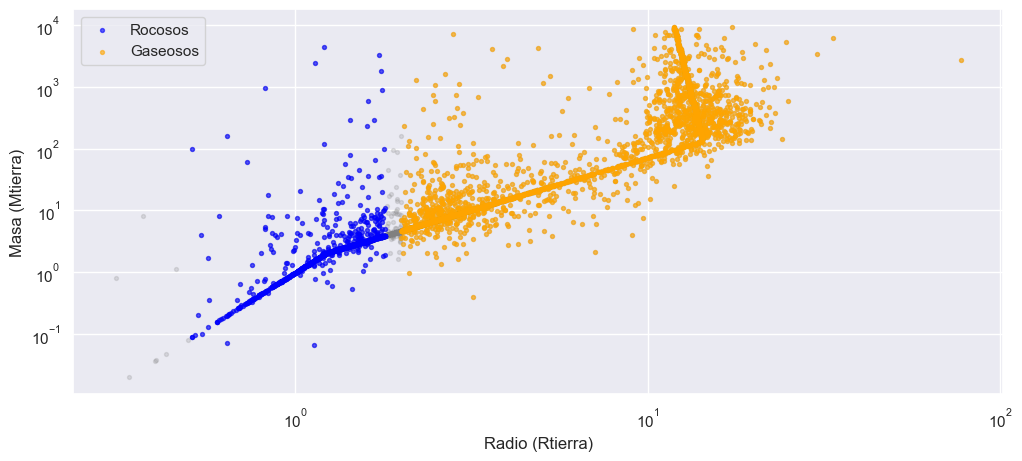

In [29]:
# Diferenciamos planetas rocosos de los gaseosos
rocosos = planets[planets['pl_rade'].between(0.5, 1.8)]
gaseosos = planets[planets['pl_rade'] > 2]

plt.figure(figsize=(12,5))
plt.scatter(planets['pl_rade'], planets['pl_bmasse'], s=8, alpha=0.2, color='gray')

plt.scatter(rocosos['pl_rade'], rocosos['pl_bmasse'], s=8, color='blue', alpha=0.6, label='Rocosos')
plt.scatter(gaseosos['pl_rade'], gaseosos['pl_bmasse'], s=8, color='orange', alpha=0.6, label='Gaseosos')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Radio (Rtierra)')
plt.ylabel('Masa (Mtierra)')
plt.legend();

La relación masa–radio revela dos poblaciones claras: planetas rocosos y gaseosos, donde destacan los gigantes gaseosos cuya masa crece muchísimo. Los planetas tipo Tierra ocupan una región muy estrecha del diagrama, lo que explica por qué son difíciles de detectar.

### Metalicidad de la Estrella vs Masa del Planeta

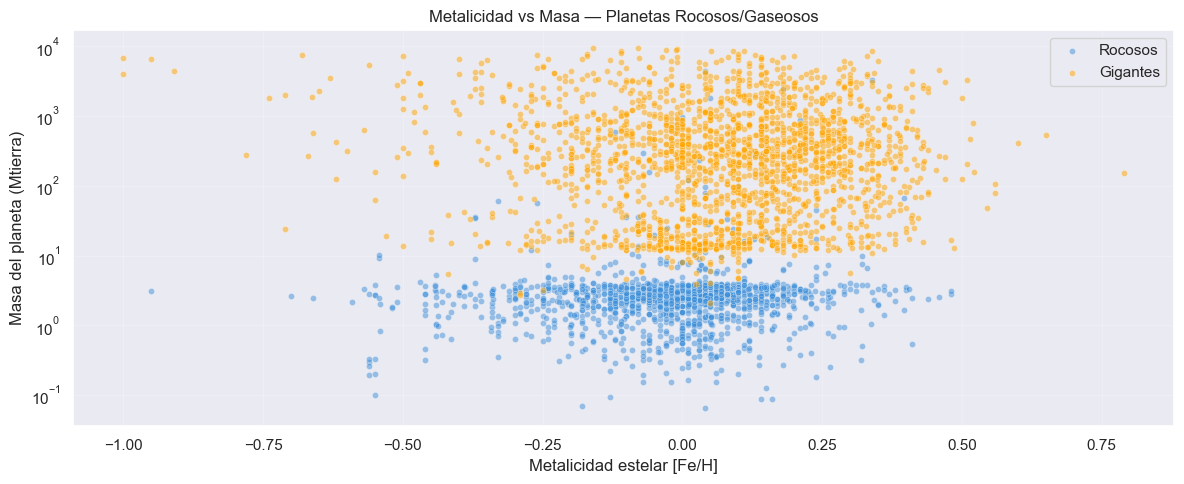

In [30]:
# Diferenciamos planetas rocosos de los gigantes
rocosos = planets[planets['pl_rade'].between(0.5, 1.8)].merge(stars[['rowid','st_met']])
gigantes = planets[planets['pl_rade'] > 3.5].merge(stars[['rowid','st_met']])

plt.figure(figsize=(12,5))
sns.scatterplot(data=rocosos,x='st_met',y='pl_bmasse',alpha=0.5,s=20,label='Rocosos')
sns.scatterplot(data=gigantes,x='st_met',y='pl_bmasse',alpha=0.5,s=20,color='orange',label='Gigantes')

plt.yscale('log')
plt.xlabel('Metalicidad estelar [Fe/H]')
plt.ylabel('Masa del planeta (Mtierra)')
plt.title('Metalicidad vs Masa — Planetas Rocosos/Gaseosos')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.legend();

La metalicidad estelar influye en la composición del sistema planetario: no afecta a los planetas rocosos, pero sí determina la probabilidad de formar gigantes gaseosos. Y es que la separación entre rocosos y gigantes frente a la metalicidad estelar es uno de los resultados más sólidos de toda la exoplanetología, y este gráfico lo refleja muy bien.

### Edad de la Estrella vs Número de Planetas

In [31]:
sub = stars[['rowid','hostname','st_age','st_spectype']].merge(systems[['rowid','sy_dist','sy_pnum']]).copy()

fig = px.scatter(
    sub,
    x='st_age',
    y='sy_pnum',
    hover_name='hostname',
    hover_data={
        'st_age': ':.2f',
        'sy_pnum': True,
        'st_spectype': True,
        'sy_dist': ':.1f'
    },
    labels={
        'st_age': 'Edad de la estrella (Gyr)',
        'sy_pnum': 'Número de planetas'
    },
    title='Edad de la estrella vs Número de planetas (Interactivo)'
)

fig.update_traces(marker=dict(size=8, opacity=0.6))
fig.update_layout(width=1000, height=650)

No encontramos una relación clara entre edad estelar y número de planetas, lo que sugiere que la formación planetaria está dominada por procesos tempranos y por sesgos observacionales, no por la evolución a largo plazo.

## Análisis por hipótesis

### Hipótesis 1

Los exoplanetas con temperaturas compatibles con agua líquida tienen radios similares al de la Tierra (y las masas?).

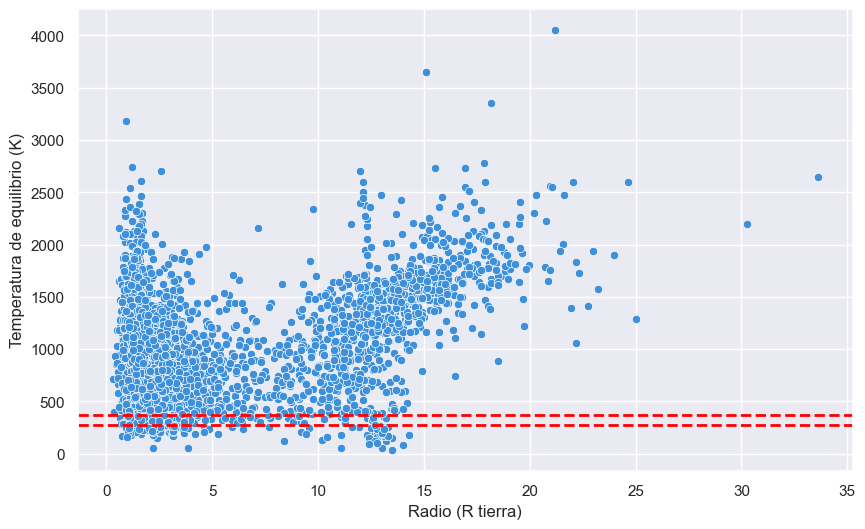

In [32]:
sub = planets[['pl_rade','pl_eqt']].copy()

plt.figure(figsize=(10,6))
sns.scatterplot(x=sub['pl_rade'],
                y=sub['pl_eqt'])

# Líneas horizontales en 273 K y 373 K
plt.axhline(y=273, color='red', linestyle='--', linewidth=2)
plt.axhline(y=373, color='red', linestyle='--', linewidth=2)

plt.xlabel('Radio (R tierra)')
plt.ylabel('Temperatura de equilibrio (K)');

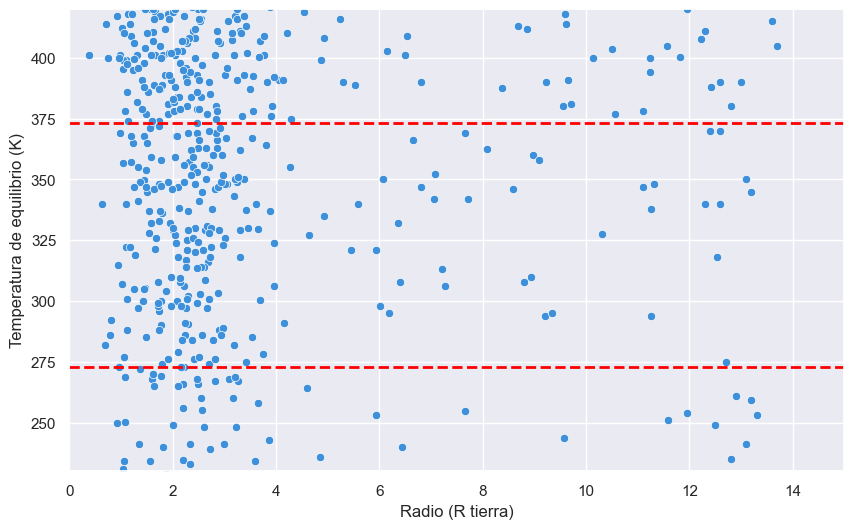

In [33]:
sub = planets[['pl_rade','pl_eqt']].copy()

plt.figure(figsize=(10,6))
sns.scatterplot(x=sub['pl_rade'],
                y=sub['pl_eqt'],
                )

# Líneas horizontales en 273 K y 373 K
plt.axhline(y=273, color='red', linestyle='--', linewidth=2)
plt.axhline(y=373, color='red', linestyle='--', linewidth=2)

plt.xlabel('Radio (R tierra)')
plt.ylabel('Temperatura de equilibrio (K)')
plt.xlim(0,15)
plt.ylim(230,420);

Parece haber una relación entre la temperatura de un planeta para la existencia de agua líquida y el tamaño. La mayoría de planetas tienen entre 1 y 4 R<sub>T</sub>.

Veamos la masa.

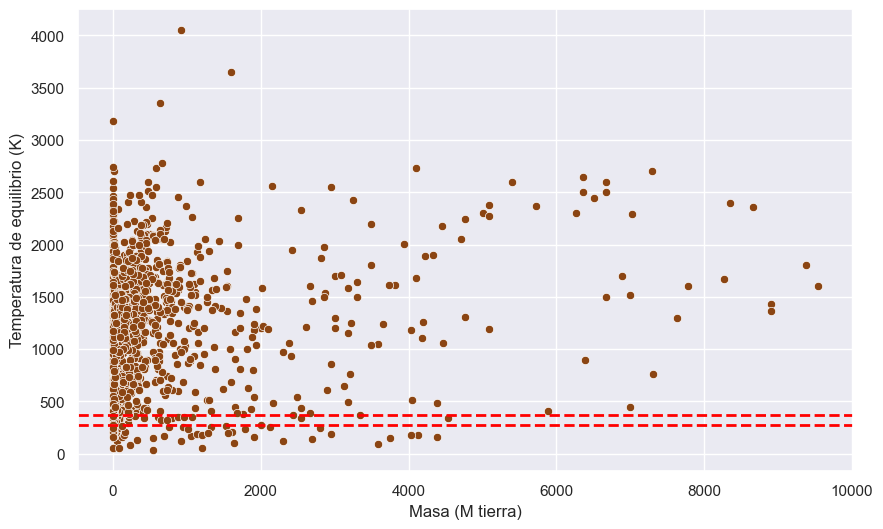

In [34]:
sub = planets[['pl_bmasse','pl_eqt']].copy()

plt.figure(figsize=(10,6))
sns.scatterplot(x=sub['pl_bmasse'],
                y=sub['pl_eqt'],
                color='saddlebrown')

# Líneas horizontales en 273 K y 373 K
plt.axhline(y=273, color='red', linestyle='--', linewidth=2)
plt.axhline(y=373, color='red', linestyle='--', linewidth=2)

plt.xlabel('Masa (M tierra)')
plt.ylabel('Temperatura de equilibrio (K)');

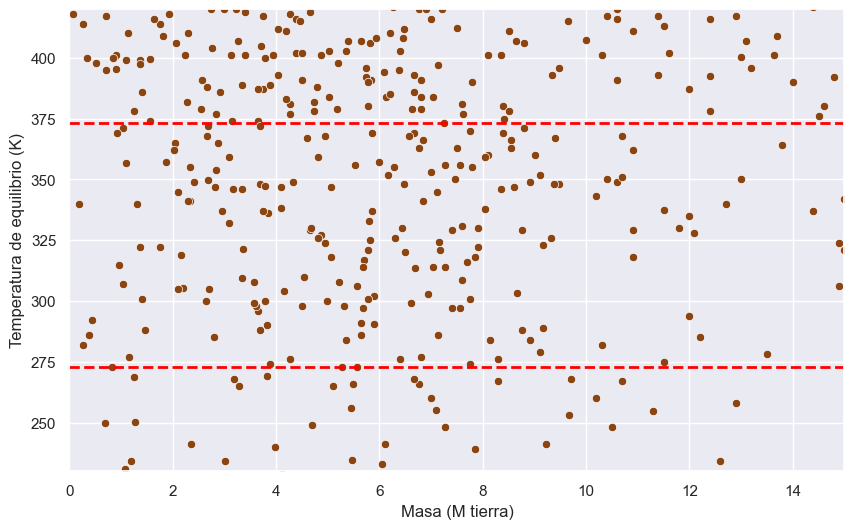

In [35]:
sub = planets[['pl_bmasse','pl_eqt']].copy()

plt.figure(figsize=(10,6))
sns.scatterplot(x=sub['pl_bmasse'],
                y=sub['pl_eqt'],
                color='saddlebrown')

# Líneas horizontales en 273 K y 373 K
plt.axhline(y=273, color='red', linestyle='--', linewidth=2)
plt.axhline(y=373, color='red', linestyle='--', linewidth=2)

plt.xlabel('Masa (M tierra)')
plt.ylabel('Temperatura de equilibrio (K)')
plt.xlim(0,15)
plt.ylim(230,420);

Los puntos están demasiado dispersos, no podemos concluir que exoplanetas con un tamaño o masa parecidos a la Tierra son más propensos de favorecer la existencia del agua líquida.

### Hipótesis 2

Los métodos actuales detectan preferentemente planetas grandes y calientes, no los más habitables.

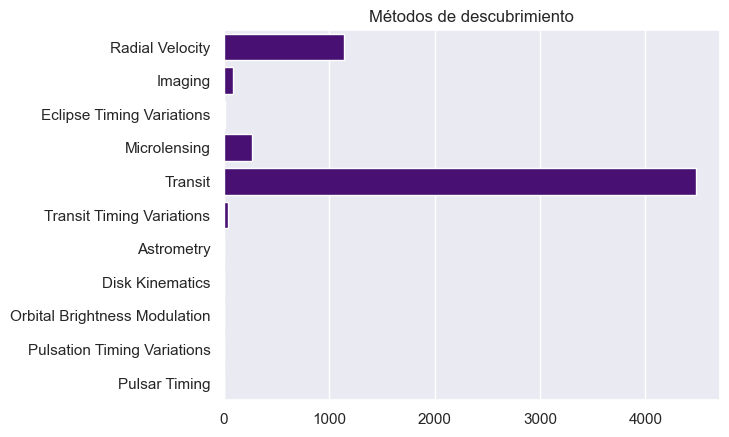

In [36]:
# Métodos más comunes
sns.countplot(data=systems, y='discoverymethod',color='indigo')
plt.title('Métodos de descubrimiento')
plt.xlabel('')
plt.ylabel('');

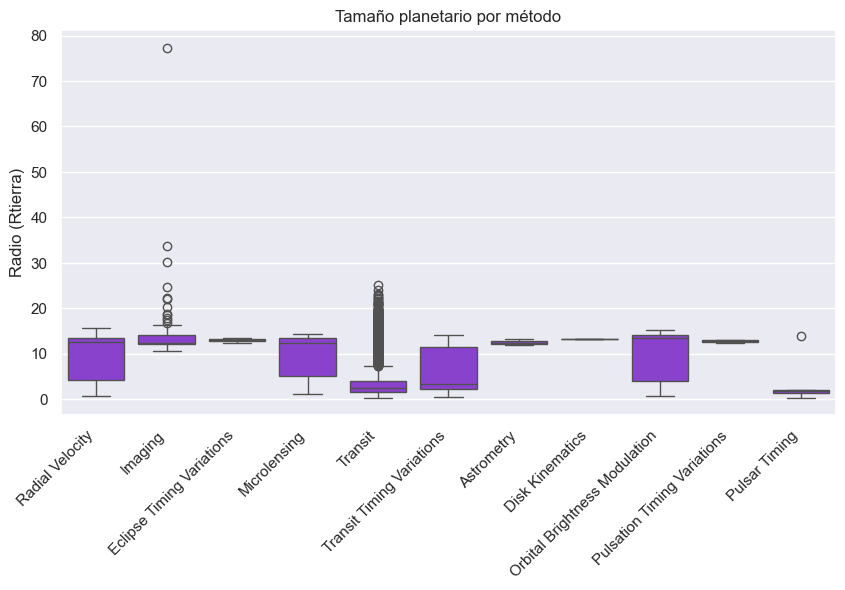

In [37]:
sub = systems[['rowid','discoverymethod']].merge(planets[['rowid','pl_rade']]).copy()

plt.figure(figsize=(10,5))
sns.boxplot(data=sub, x='discoverymethod', y='pl_rade', color='blueviolet')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Radio (Rtierra)')
plt.xlabel('')
plt.title('Tamaño planetario por método');

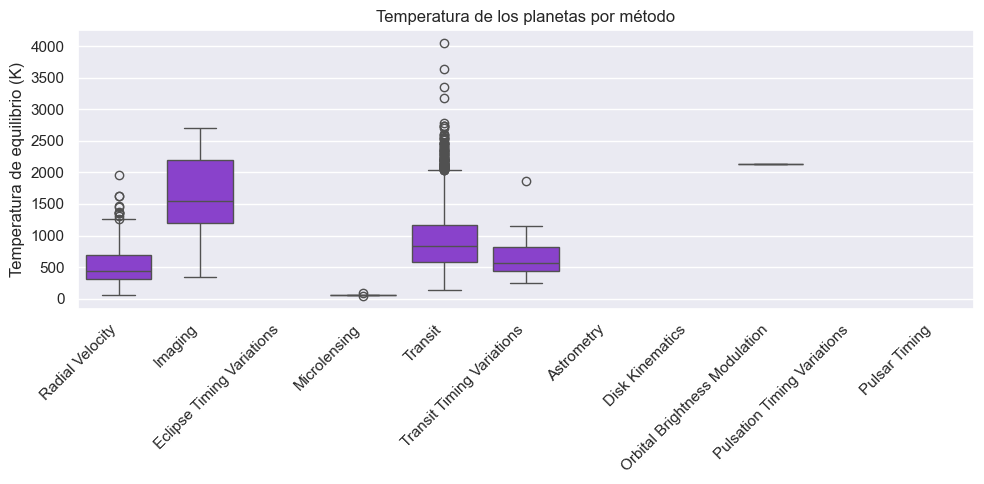

In [38]:
sub = systems[['rowid','discoverymethod']].merge(planets[['rowid','pl_eqt']]).copy()

plt.figure(figsize=(10,5))
sns.boxplot(data=sub, x='discoverymethod', y='pl_eqt', color='blueviolet')
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('Temperatura de equilibrio (K)')
plt.title('Temperatura de los planetas por método')
plt.tight_layout();

In [39]:
sub = systems[['rowid','discoverymethod']].merge(planets[['rowid','pl_insol','pl_rade']]).copy()

fig = px.scatter(sub,
                 x='pl_insol',
                 y='pl_rade',
                 color='discoverymethod',
                 hover_data={'pl_insol': ':.2f', 'pl_rade': ':.2f'},
                 labels={'pl_insol':'Insolación (rel. Tierra)','pl_rade':'Radio (Rtierra)','discoverymethod':'Método de descubrimiento'},
                 title='Tamaño vs Insolación por método'
                 )

fig.update_xaxes(type='log')
fig.update_traces(marker=dict(size=7, opacity=0.7))

Los métodos principales (Transit y RV) detectan mayormente planetas calientes. Los planetas fríos están casi ausentes no porque no existan, sino porque nos cuesta mucho más detectarlos.

Buscamos los que son habitables, según nuestro criterio de habitabilidad.

In [40]:
# Creamos columna nueva indicando si es similar a la Tierra
# Rocosos (radios de 0.5 - 1.8 Rtierra)
# Insolación relativa 0.35 - 1.7
sub = systems[['rowid','discoverymethod']].merge(planets[['rowid','pl_name','pl_insol','pl_rade']]).copy()

sub['tipo_tierra'] = sub['pl_rade'].between(0.5, 1.8) & sub['pl_insol'].between(0.35, 1.7)

In [41]:
fig = px.scatter(
    sub,
    x='pl_insol',
    y='pl_rade',
    color='tipo_tierra',
    hover_name='pl_name',
    hover_data={'pl_insol': ':.2f', 'pl_rade': ':.2f', 'discoverymethod': True},
    labels={'pl_insol':'Insolación (rel. Tierra)', 'pl_rade':'Radio (Rtierra)', 'tipo_tierra':'Habitable'},
    title='Planetas detectados vs Planetas habitables'
)

fig.update_xaxes(type='log')
fig.update_traces(marker=dict(size=7, opacity=0.7))

In [42]:
fig = px.scatter(
    sub,
    x='pl_insol',
    y='pl_rade',
    color='discoverymethod',
    symbol='tipo_tierra',
    hover_name='pl_name',
    labels={'pl_insol':'Insolación', 'pl_rade':'Radio','discoverymethod':'Método de descubrimiento','tipo_tierra':'Habitable'},
    title='Método de descubrimiento vs Habitabilidad'
)

fig.update_xaxes(type='log')
fig.update_traces(marker=dict(size=7, opacity=0.7))

Al comparar el conjunto total de exoplanetas detectados con los planetas potencialmente habitables (rocosos y con insolación adecuada), se observa que una mínima parte de las detecciones actuales corresponden a mundos habitables. La mayoría de los métodos, en especial Transit y Radial Velocity— están optimizados para detectar planetas grandes y calientes, mientras que los planetas pequeños y fríos, que serían los más parecidos a la Tierra, quedan prácticamente fuera de nuestro alcance. Esto implica que la aparente escasez de planetas habitables podría deberse a un sesgo observacional, no una propiedad real de la galaxia.

### Hipótesis 3

Las estrellas más estables (actividad baja) tienen más planetas potencialmente habitables.

Para poder analizar esto debemos definir nuestro criterio de actividad.

In [43]:
sub = stars[['rowid','st_spectype','st_age','st_rotp']].merge(planets[['rowid','pl_rade','pl_insol']]).copy()

# Tipo Tierra
sub['tipo_tierra'] = sub['pl_rade'].between(0.5, 1.8) & sub['pl_insol'].between(0.35, 1.7)

# 1. Actividad inversamente proporcional a la edad
sub['act_age'] = 1 / sub['st_age']

# 2. Actividad inversamente proporcional al periodo de rotación
sub['act_rot'] = 1 / sub['st_rotp']

# 3. Actividad por tipo espectral
def spectral_activity(s):
    if pd.isna(s): return None
    if s.startswith('M'): return 3
    if s.startswith('K'): return 2
    if s.startswith('G'): return 1
    if s.startswith('F'): return 0.5
    return 0.2

sub['act_spec'] = sub['st_spectype'].apply(spectral_activity)


sub['st_act'] = (0.5 * sub['act_age'].rank(pct=True) +
                 0.3 * sub['act_rot'].rank(pct=True) +
                 0.2 * sub['act_spec'].rank(pct=True)
)

In [44]:
sub['act_bin'] = pd.qcut(sub['st_act'], 4, labels=['Muy baja','Baja','Media','Alta'])
sub.groupby('act_bin')['tipo_tierra'].mean()

act_bin
Muy baja    0.048951
Baja        0.028169
Media       0.034722
Alta        0.000000
Name: tipo_tierra, dtype: float64

In [45]:
# Calculamos porcentaje de habitables por actividad
sub['act_bin'] = pd.Categorical(sub['act_bin'], 
                               categories=['Muy baja','Baja','Media','Alta'],
                               ordered=True)

summary = sub.groupby('act_bin')['tipo_tierra'].mean() * 100

fig = px.bar(
    summary.reset_index(),
    x='act_bin',
    y='tipo_tierra',
    color_discrete_sequence=['#CA3143'],
    labels={'act_bin':'Actividad estelar','tipo_tierra':''},
    title='Porcentaje de planetas habitables por nivel de actividad',
    text='tipo_tierra' # Porcentaje de los datos
)

# Formato del texto: 1 decimal + símbolo %
fig.update_traces(
    texttemplate='%{text:.1f}%', 
    textposition='outside'
)

# Dejamos espacio arriba para las etiquetas
fig.update_layout(
    yaxis_range=[0, summary.max()*1.15]
)

No se observa una relación fuerte entre actividad estelar y habitabilidad, probablemente porque los datos actuales son insuficientes. Sin embargo, se aprecia una ligera tendencia a que las estrellas más estables alberguen más planetas potencialmente habitables.

### Hipótesis 4

El porcentaje de planetas 'Tipo Tierra' es extremadamente bajo dentro del catálogo conocido.

In [46]:
sub = planets[['rowid','pl_rade','pl_insol','pl_bmasse','pl_eqt']].copy()

sub['tipo_tierra'] = (
    sub['pl_rade'].between(0.5, 2) &      # Rocosos: radios similares al de la Tierra (0.5 - 2 R tierra)
    sub['pl_insol'].between(0.35, 1.7) &  # Insolación relativa 0.35 - 1.7
    sub['pl_bmasse'].between(0.5, 5)      # Masa similar al de la Tierra (0.5 - 5 M tierra)
)

In [47]:
# Calculamos porcentaje de planetas Tipo Tierra
total = len(sub)
tipo_tierra_count = sub['tipo_tierra'].sum()
porcentaje = 100 * tipo_tierra_count / total

total, tipo_tierra_count, porcentaje

(6053, np.int64(37), np.float64(0.6112671402610276))

In [48]:
summary = pd.DataFrame({
    'Tipo': ['Habitables', 'No habitables'],
    'Cantidad': [tipo_tierra_count, total - tipo_tierra_count]
})

fig = px.bar(
    summary,
    x='Tipo',
    y='Cantidad',
    color_discrete_sequence=['#576C32'],
    title='Planetas Tipo Tierra vs Resto',
    text='Cantidad'
)

fig.update_layout(yaxis_title='Número de planetas')
fig.show();

El catálogo actual de exoplanetas está dominado por planetas grandes y calientes debido, principalmente, a los sesgos de los métodos de detección. Al aplicar criterios razonables de habitabilidad (radio y masa terrestres, insolación adecuada), menos del 1% de los planetas detectados pueden considerarse ‘Tipo Tierra’. Esta escasez no refleja la verdadera abundancia de mundos habitables en la galaxia, sino las limitaciones tecnológicas actuales.

### Hipótesis 5

La mayoría de las estrellas cercanas no cumplen simultáneamente condiciones para la vida inteligente (edad, estabilidad, metalicidad, 'Tipo Tierra',...).

In [49]:
sub = planets[['rowid','pl_rade','pl_insol','pl_bmasse']].merge(stars[['rowid','st_met','st_rotp','st_spectype','st_age']]).merge(systems[['rowid','sy_dist']]).copy()

# Planeta Tipo Tierra
sub['tipo_tierra'] = (sub['pl_rade'].between(0.5, 2) &      # Rocosos: radios similares al de la Tierra (0.5 - 2 R tierra)
                      sub['pl_insol'].between(0.35, 1.7) &  # Insolación relativa 0.35 - 1.7
                      sub['pl_bmasse'].between(0.5, 3)      # Masa similar al de la Tierra (0.5 - 3 M tierra)
)


# Edad mayor a 4 Gyr
sub['edad_ok'] = sub['st_age'] > 4


# Metalicidad entre -0.5 y 0.3 [Fe/H]
sub['met_ok'] = sub['st_met'].between(-0.5, 0.3)


# Estabilidad. Estrellas con actividad baja
# 1. Actividad inversamente proporcional a la edad
sub['act_age'] = 1 / sub['st_age']
# 2. Actividad inversamente proporcional al periodo de rotación
sub['act_rot'] = 1 / sub['st_rotp']
# 3. Actividad por tipo espectral
def spectral_activity(s):
    if pd.isna(s): return None
    if s.startswith('M'): return 3
    if s.startswith('K'): return 2
    if s.startswith('G'): return 1
    if s.startswith('F'): return 0.5
    return 0.2
sub['act_spec'] = sub['st_spectype'].apply(spectral_activity)
sub['st_act'] = (0.5 * sub['act_age'].rank(pct=True) +
                 0.3 * sub['act_rot'].rank(pct=True) +
                 0.2 * sub['act_spec'].rank(pct=True)
                 )
sub['act_ok'] = sub['st_act'] < sub['st_act'].quantile(0.25) # Nos quedamos con el primer cuartil


# Cercanía. A no más de 50-100 pc
sub['cerca'] = sub['sy_dist'] < 75


# Estrellas adecuadas
sub['star_ok'] = (sub['edad_ok'] &
                  sub['met_ok'] &
                  sub['act_ok'] &
                  sub['cerca']
                  )


# Planetas candidatos para albergar vida inteligente
sub['candidato'] = sub['star_ok'] & sub['tipo_tierra']

In [50]:
# Calculamos porcentaje de planetas en estrellas cercanas 
total = len(sub)
validos_count = sub['cerca'].sum()
porcentaje = 100 * validos_count / total

print(f'Porcentaje de planetas válidos: {round(porcentaje,3)} %')

summary = pd.DataFrame({'Tipo': ['Válidos', 'Resto'],
                        'Cantidad': [validos_count, total - validos_count]
                        })

fig = px.bar(summary,
             x='Tipo',
             y='Cantidad',
             color_discrete_sequence=['#3591A8'],
             title='Planetas en estrellas cercanas vs Resto',
             text='Cantidad'
             )

fig.update_layout(yaxis_title='Número de planetas')
fig.show();

Porcentaje de planetas válidos: 20.965 %


In [51]:
# Calculamos porcentaje de planetas en estrellas cercanas que cumplen edad + metalicidad + estabilidad
total = len(sub)
validos_count = sub['star_ok'].sum()
porcentaje = 100 * validos_count / total

print(f'Porcentaje de planetas válidos: {round(porcentaje,3)} %')

summary = pd.DataFrame({'Tipo': ['Válidos', 'Resto'],
                        'Cantidad': [validos_count, total - validos_count]
                        })

fig = px.bar(summary,
             x='Tipo',
             y='Cantidad',
             color_discrete_sequence=['#C45603'],
             title='Planetas en estrellas válidas vs Resto',
             text='Cantidad'
             )

fig.update_layout(yaxis_title='Número de planetas')
fig.show();

Porcentaje de planetas válidos: 1.272 %


In [52]:
# Porcentaje de candidatos (cumplen todas las condiciones)
total = len(sub)
candidatos_count = sub['candidato'].sum()
porcentaje = 100 * candidatos_count / total

print(f'Porcentaje de planetas candidatos: {round(porcentaje,3)} %')

summary = pd.DataFrame({'Tipo': ['Candidatos', 'Resto'],
                        'Cantidad': [candidatos_count, total - candidatos_count]
                        })

fig = px.bar(summary,
             x='Tipo',
             y='Cantidad',
             color_discrete_sequence=['#8003C4'],
             title='Planetas candidatos vs Resto',
             text='Cantidad'
             )

fig.update_layout(yaxis_title='Número de planetas')
fig.show();

Porcentaje de planetas candidatos: 0.083 %


Al aplicar simultáneamente criterios razonables para la vida inteligente (edad suficiente, baja actividad, metalicidad adecuada y presencia de planetas rocosos en la zona habitable) el número de estrellas cercanas que los cumplen es extraordinariamente bajo, típicamente por debajo del 0.1% del catálogo. Esta escasez no refleja la verdadera abundancia de sistemas habitables en la galaxia, sino las limitaciones observacionales actuales: la mayoría de las estrellas cercanas carecen de datos completos sobre actividad, planetas pequeños o zonas habitables. En otras palabras, no es que falten mundos adecuados, sino que aún no podemos detectarlos.

In [61]:
# Mostramos datos en un funnel chart
etapas = [
    'Total estrellas',
    'Cercanas (<75 pc)',
    'Cercanas + estables + metalicidad adecuada',
    # 'Con planeta rocoso en zona habitable',
    'Candidatos finales'
]

valores = [
    6053,       # 100%
    1269,       # 21%
    77,         # 1.27%
    5           # 0.083%
]

df_funnel = pd.DataFrame({'Etapa': etapas, 'Valor': valores})
df_funnel = df_funnel.sort_values('Valor', ascending=True)

fig = px.funnel(
    df_funnel,
    x='Valor',
    y='Etapa',
    title='Filtros para vida inteligente en estrellas cercanas',
    color='Etapa'
)

fig.update_yaxes(title_text='')

fig.update_layout(funnelmode='stack',
                  funnelgap=0,
                  yaxis_title=None
                  )

fig.show()

La distancia es un factor crítico en el análisis de habitabilidad. Las estrellas cercanas son las únicas para las que disponemos de datos fiables sobre edad, actividad, metalicidad y presencia de planetas pequeños. Las estrellas lejanas carecen de esta información debido a limitaciones observacionales, por lo que incluirlas distorsiona cualquier estimación sobre la prevalencia de sistemas aptos para la vida inteligente. Por ello, el análisis debe restringirse a estrellas dentro de un radio cercano, donde los datos son completos y comparables.

### Hipótesis 6

La distancia media entre planetas potencialmente habitables es tan grande que la comunicación entre sí o viajes interestelares es muy improbable.

In [54]:
# De H5, tenemos 5 planetas candidatos de albergar vida inteligente en un radio de 75 pc
N = 5
R = 75

# Densidad espacial. Suponemos densidad homogénea
# 𝑉 = 4/3 𝜋 𝑅**3
V = 4/3 * math.pi * R**3
n = N/V # Densidad de candidatos
# n ~ 3e-6

# Separación típica entre objetos en un gas/distribución homogénea
d = n**(-1/3)
d_al = d * 3.262
print(f'{d} pc')
print(f'{d_al} años luz')
# d ~ 70 pc ~ 230 años luz 

70.70239601100862 pc
230.6312157879101 años luz


Con una separación promedio de 230 años luz, una respuesta a un mensaje tardaría en llegar al menos 460 años. En el caso de viajes interestelares, incluso a 0.1c tardaríamos 2300 años en llegar y eso que actualmente la mayor velocidad alcanzada por una nave tripulada está en los 39 937,7 km/h. A esta velocidad constante tardaríamos más de 6 millones de años en llegar.

Si tomamos los planetas potencialmente habitables detectados dentro de un radio de 75 pc y estimamos su densidad espacial, obtenemos una separación típica del orden de centenares de años luz entre ellos. A estas distancias, incluso la comunicación a la velocidad de la luz implica tiempos de respuesta de siglos, y los viajes interestelares requerirían escalas temporales muy superiores a una vida humana. En el catálogo conocido, los mundos habitables no solo son escasos, sino también extremadamente aislados entre sí.